# Model 2 — LASSO Monthly: อะไร drive SET Index Returns?

**Data:** Monthly market signals + FRED indicators (N≈275, 2003–2025)

**Target:** `SET_index_ret_m` (monthly return)

**Models:**
- **2a** — Explanatory: SET_ret[t] ~ all monthly features[t] (contemporaneous)
- **2b** — Predictive:  SET_ret[t+1] ~ all monthly features[t] (true forecasting, no look-ahead)

**LASSO** ถูกเลือกเพราะ:
1. มี ~20 features → LASSO ทำ automatic feature selection (shrink บางตัวเป็น 0)
2. หลีกเลี่ยง overfitting ด้วย L1 penalty
3. เลือก alpha ด้วย TimeSeriesSplit cross-validation (ไม่ leak อนาคต)

**Train/Test split:** 2003–2019 (train) | 2020–2025 (test) — แยก COVID period ออกเป็น out-of-sample

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

PROC_DIR = Path('../../data/processed')

# ── Load data ─────────────────────────────────────────────────────────────────
unified = pd.read_csv(PROC_DIR / 'unified_monthly.csv', index_col=0, parse_dates=True)

# Monthly features only (no forward-filled annual data)
MARKET_RET = [c for c in unified.columns if c.endswith('_ret_m') and c != 'SET_index_ret_m']
FRED_LEVEL = [c for c in unified.columns if not c.endswith(('_ret_m', '_price', '_annual'))]

TARGET = 'SET_index_ret_m'

# FRED: use MoM % change (remove trend, make stationary)
fred_ret = unified[FRED_LEVEL].pct_change().replace([np.inf, -np.inf], np.nan)
fred_ret.columns = [f'{c}_mom' for c in fred_ret.columns]

# Combine features
features_df = pd.concat([unified[MARKET_RET], fred_ret], axis=1)
ALL_FEATURES = list(features_df.columns)

# Full dataset
data = pd.concat([features_df, unified[[TARGET]]], axis=1).dropna()

# Train/test split (time-based)
TRAIN_END = '2019-12-31'
TEST_START = '2020-01-01'
train = data[data.index <= TRAIN_END]
test  = data[data.index >= TEST_START]

print(f'Total rows   : {len(data)}  ({data.index[0].date()} → {data.index[-1].date()})')
print(f'Train rows   : {len(train)}  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test rows    : {len(test)}  ({test.index[0].date()} → {test.index[-1].date()})')
print(f'Features     : {len(ALL_FEATURES)}')
print()
print('Feature groups:')
print(f'  Market returns (monthly): {MARKET_RET}')
print(f'  FRED MoM changes        : {[f for f in ALL_FEATURES if f.endswith("_mom")]}')

Total rows   : 231  (2004-01-31 → 2025-12-31)
Train rows   : 166  (2004-01-31 → 2019-10-31)
Test rows    : 65  (2020-02-29 → 2025-12-31)
Features     : 18

Feature groups:
  Market returns (monthly): ['USD_THB_ret_m', 'vix_ret_m', 'gold_ret_m', 'oil_ret_m', 'sp500_ret_m', 'us_10yr_treasury_ret_m', 'nasdaq_ret_m']
  FRED MoM changes        : ['th_exchange_rate_real_mom', 'th_us_imports_mom', 'th_property_prices_mom', 'th_uncertainty_mom', 'us_fed_funds_rate_mom', 'us_cpi_monthly_mom', 'us_unemployment_mom', 'us_industrial_prod_mom', 'global_uncertainty_mom', 'us_consumer_sentiment_mom', 'us_govt_spending_mom']


---
## Step 1 — Feature Overview: Correlation with SET Returns

ดูก่อน baseline correlation (ไม่มี lag) ว่า feature ไหน relate กับ SET มากที่สุด

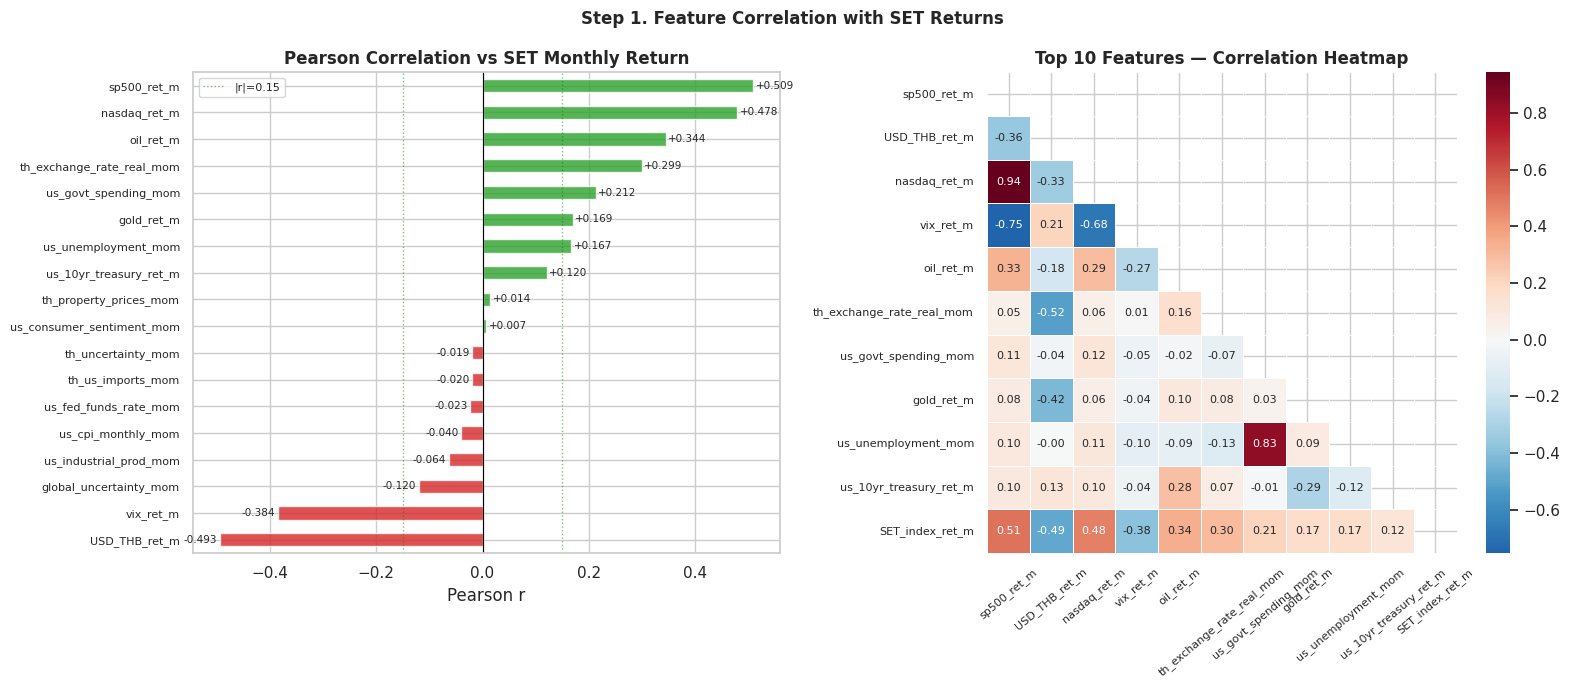

Top 5 positive correlations with SET:
us_govt_spending_mom         0.2125
th_exchange_rate_real_mom    0.2989
oil_ret_m                    0.3438
nasdaq_ret_m                 0.4778
sp500_ret_m                  0.5087

Top 5 negative correlations with SET:
USD_THB_ret_m            -0.4934
vix_ret_m                -0.3842
global_uncertainty_mom   -0.1197
us_industrial_prod_mom   -0.0637
us_cpi_monthly_mom       -0.0404


In [2]:
corr_vs_set = data[ALL_FEATURES].corrwith(data[TARGET]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Correlation bar chart
colors = ['tab:red' if v < 0 else 'tab:green' for v in corr_vs_set]
corr_vs_set.plot(kind='barh', ax=axes[0], color=colors, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(0.15,  color='green', linestyle=':', linewidth=1, alpha=0.5, label='|r|=0.15')
axes[0].axvline(-0.15, color='green', linestyle=':', linewidth=1, alpha=0.5)
for j, (feat, val) in enumerate(corr_vs_set.items()):
    axes[0].text(val + (0.005 if val >= 0 else -0.005), j,
                 f'{val:+.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=7.5)
axes[0].set_title('Pearson Correlation vs SET Monthly Return',
                   fontweight='bold')
axes[0].set_xlabel('Pearson r')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Full heatmap (top 10 abs corr features)
top10 = corr_vs_set.abs().nlargest(10).index
corr_top = data[list(top10) + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 8})
axes[1].set_title('Top 10 Features — Correlation Heatmap', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Step 1. Feature Correlation with SET Returns', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 positive correlations with SET:')
print(corr_vs_set.tail(5).round(4).to_string())
print()
print('Top 5 negative correlations with SET:')
print(corr_vs_set.head(5).round(4).to_string())

---
## Model 2a — Explanatory LASSO (Contemporaneous)

SET_ret[t] ~ features[t] — ดูว่า factors ไหน *relate* กับ SET ในเดือนเดียวกัน

> **ไม่ใช่ forecasting** — ใช้เพื่อ interpretation เท่านั้น (เพราะ features รู้พร้อมกัน)

In [3]:
def fit_lasso_model(X_train, y_train, X_test, y_test, feature_names, title):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_te_s = scaler.transform(X_test)

    tscv = TimeSeriesSplit(n_splits=5)
    alphas = np.logspace(-5, 1, 100)
    lasso_cv = LassoCV(alphas=alphas, cv=tscv, max_iter=10000).fit(X_tr_s, y_train)

    # Refit on full train with best alpha
    lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000).fit(X_tr_s, y_train)

    y_pred_train = lasso.predict(X_tr_s)
    y_pred_test  = lasso.predict(X_te_s)

    metrics = {
        'alpha':      lasso_cv.alpha_,
        'train_r2':   r2_score(y_train, y_pred_train),
        'test_r2':    r2_score(y_test,  y_pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse':  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'test_mae':   mean_absolute_error(y_test, y_pred_test),
    }

    coef_df = pd.DataFrame({
        'feature':    feature_names,
        'coef_std':   lasso.coef_,
    })
    coef_df = coef_df[coef_df['coef_std'] != 0].sort_values('coef_std')

    print(f'{title}')
    print(f'  α={metrics["alpha"]:.6f}  |  '
          f'Features selected: {len(coef_df)}/{len(feature_names)}')
    print(f'  Train R²={metrics["train_r2"]:.3f}  RMSE={metrics["train_rmse"]:.4f}')
    print(f'  Test  R²={metrics["test_r2"]:.3f}  RMSE={metrics["test_rmse"]:.4f}  MAE={metrics["test_mae"]:.4f}')
    print()

    return lasso, scaler, coef_df, metrics, y_pred_train, y_pred_test

X_train_2a = train[ALL_FEATURES].values
y_train_2a = train[TARGET].values
X_test_2a  = test[ALL_FEATURES].values
y_test_2a  = test[TARGET].values

lasso_2a, scaler_2a, coef_2a, metrics_2a, yhat_tr_2a, yhat_te_2a = fit_lasso_model(
    X_train_2a, y_train_2a, X_test_2a, y_test_2a,
    ALL_FEATURES, 'Model 2a — Explanatory LASSO (contemporaneous)')

Model 2a — Explanatory LASSO (contemporaneous)
  α=0.007055  |  Features selected: 4/18
  Train R²=0.430  RMSE=0.0365
  Test  R²=0.254  RMSE=0.0432  MAE=0.0342



---
## Model 2b — Predictive LASSO (Next-Month Forecast)

SET_ret[t+1] ~ features[t] — **true forecasting** ไม่มี look-ahead bias

- Lag target ไปข้างหน้า 1 เดือน (shift -1)
- Features เดือนนี้ → ทำนาย SET เดือนหน้า
- นี่คือ model ที่ใช้งานจริงได้

In [4]:
# Shift target forward 1 month
data_pred = data.copy()
data_pred['target_next'] = data_pred[TARGET].shift(-1)
data_pred = data_pred.dropna()

train_pred = data_pred[data_pred.index <= TRAIN_END]
test_pred  = data_pred[data_pred.index >= TEST_START]

X_train_2b = train_pred[ALL_FEATURES].values
y_train_2b = train_pred['target_next'].values
X_test_2b  = test_pred[ALL_FEATURES].values
y_test_2b  = test_pred['target_next'].values

lasso_2b, scaler_2b, coef_2b, metrics_2b, yhat_tr_2b, yhat_te_2b = fit_lasso_model(
    X_train_2b, y_train_2b, X_test_2b, y_test_2b,
    ALL_FEATURES, 'Model 2b — Predictive LASSO (next-month forecast)')

Model 2b — Predictive LASSO (next-month forecast)
  α=10.000000  |  Features selected: 0/18
  Train R²=0.000  RMSE=0.0486
  Test  R²=-0.009  RMSE=0.0487  MAE=0.0348



---
## Visualization — Coefficients & Prediction Quality

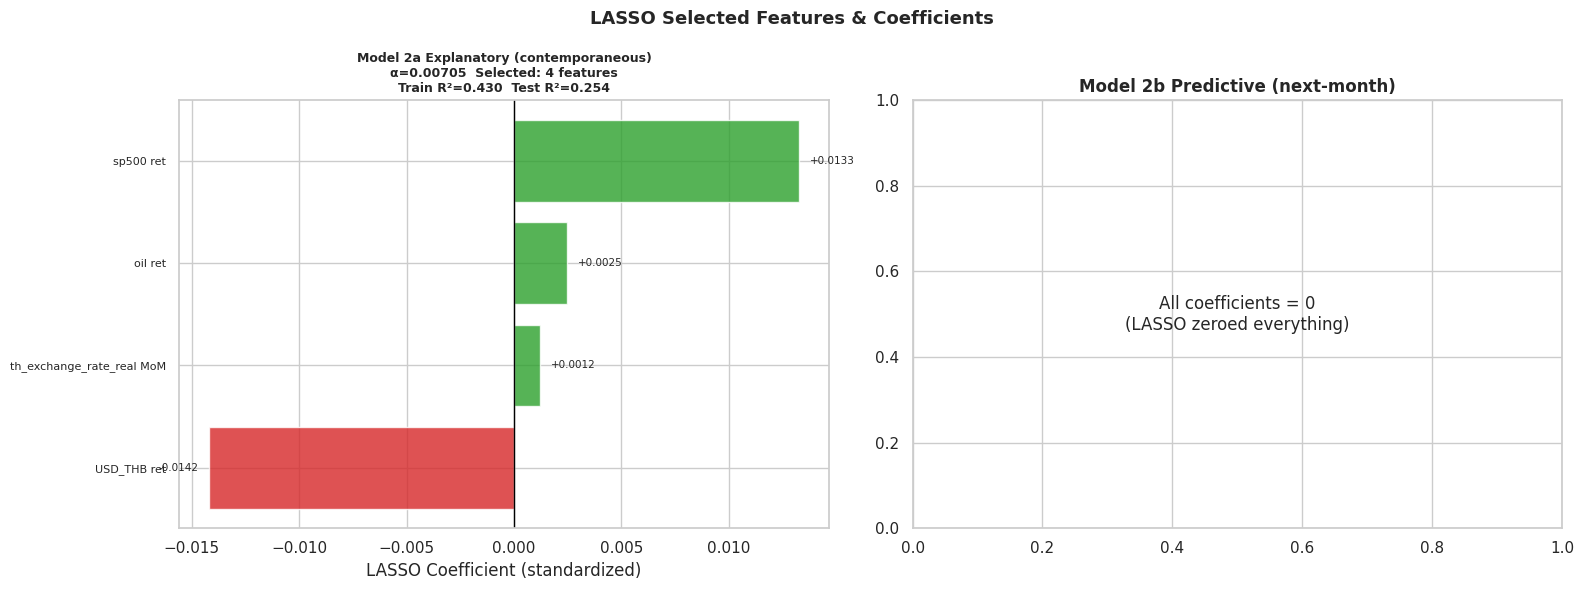

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, max(len(coef_2a), len(coef_2b)) * 0.4 + 2)))

for ax, coef_df, metrics, label in [
    (axes[0], coef_2a, metrics_2a, '2a Explanatory (contemporaneous)'),
    (axes[1], coef_2b, metrics_2b, '2b Predictive (next-month)'),
]:
    if len(coef_df) == 0:
        ax.text(0.5, 0.5, 'All coefficients = 0\n(LASSO zeroed everything)',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Model {label}', fontweight='bold')
        continue

    colors_c = ['tab:green' if v > 0 else 'tab:red' for v in coef_df['coef_std']]
    clean_names = coef_df['feature'].str.replace('_ret_m', ' ret').str.replace('_mom', ' MoM')
    ax.barh(clean_names, coef_df['coef_std'], color=colors_c, alpha=0.8)
    ax.axvline(0, color='black', linewidth=1)
    for j, (_, row) in enumerate(coef_df.iterrows()):
        ax.text(row['coef_std'] + (0.0005 if row['coef_std'] >= 0 else -0.0005), j,
                f"{row['coef_std']:+.4f}", va='center',
                ha='left' if row['coef_std'] >= 0 else 'right', fontsize=7.5)
    ax.set_title(f'Model {label}\n'
                 f'α={metrics["alpha"]:.5f}  Selected: {len(coef_df)} features\n'
                 f'Train R²={metrics["train_r2"]:.3f}  Test R²={metrics["test_r2"]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('LASSO Coefficient (standardized)')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('LASSO Selected Features & Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

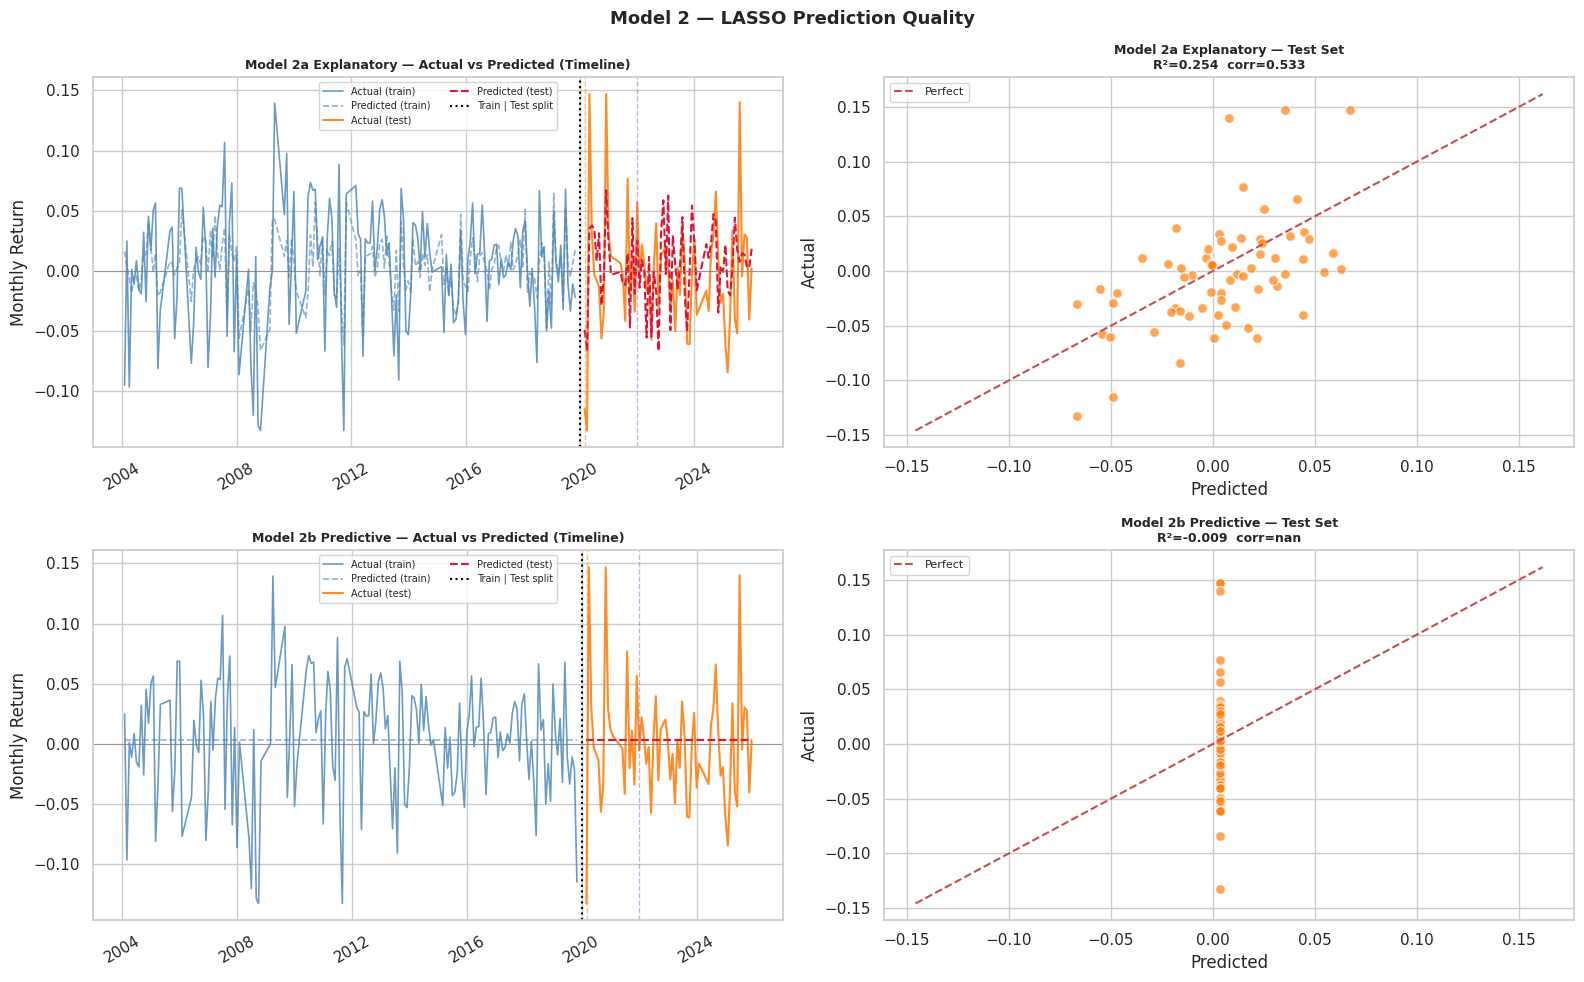

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

EVENTS = {
    'COVID Mar\n2020': ('2020-03', 'tab:orange'),
    'Rate Hike\n2022': ('2022-01', 'tab:purple'),
}

for row_i, (model_label, train_data, test_data,
             y_tr, y_te, yhat_tr, yhat_te) in enumerate([
    ('2a Explanatory', train, test,
     y_train_2a, y_test_2a, yhat_tr_2a, yhat_te_2a),
    ('2b Predictive',  train_pred, test_pred,
     y_train_2b, y_test_2b, yhat_tr_2b, yhat_te_2b),
]):
    # Timeline plot
    ax_t = axes[row_i][0]
    ax_t.plot(train_data.index, y_tr,    color='steelblue',  linewidth=1.2, alpha=0.8, label='Actual (train)')
    ax_t.plot(train_data.index, yhat_tr, color='steelblue',  linewidth=1.2, linestyle='--', alpha=0.6, label='Predicted (train)')
    ax_t.plot(test_data.index,  y_te,    color='tab:orange', linewidth=1.5, alpha=0.9, label='Actual (test)')
    ax_t.plot(test_data.index,  yhat_te, color='crimson',    linewidth=1.5, linestyle='--', label='Predicted (test)')

    # Train/test divider
    ax_t.axvline(pd.Timestamp(TEST_START), color='black', linewidth=1.5,
                 linestyle=':', label='Train | Test split')
    ax_t.axhline(0, color='gray', linewidth=0.5)
    for evt_name, (evt_date, evt_color) in EVENTS.items():
        ax_t.axvline(pd.Timestamp(evt_date), color=evt_color, alpha=0.5,
                     linestyle='--', linewidth=1)

    ax_t.set_title(f'Model {model_label} — Actual vs Predicted (Timeline)',
                   fontweight='bold', fontsize=9)
    ax_t.set_ylabel('Monthly Return')
    ax_t.legend(fontsize=7, ncol=2)
    ax_t.tick_params(axis='x', rotation=30)

    # Scatter test set only
    ax_s = axes[row_i][1]
    ax_s.scatter(yhat_te, y_te, alpha=0.7, color='tab:orange',
                 s=50, edgecolors='white')
    lo = min(yhat_te.min(), y_te.min()) * 1.1
    hi = max(yhat_te.max(), y_te.max()) * 1.1
    ax_s.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect')
    ax_s.set_xlabel('Predicted'); ax_s.set_ylabel('Actual')
    test_r2 = r2_score(y_te, yhat_te)
    test_corr = np.corrcoef(yhat_te, y_te)[0, 1]
    ax_s.set_title(f'Model {model_label} — Test Set\n'
                   f'R²={test_r2:.3f}  corr={test_corr:.3f}',
                   fontweight='bold', fontsize=9)
    ax_s.legend(fontsize=8)

plt.suptitle('Model 2 — LASSO Prediction Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Direction Accuracy — ทำนายทิศทาง (ขึ้น/ลง) ถูกแค่ไหน?

R² ต่ำไม่ได้แปลว่า model ไม่มีประโยชน์ — ถ้าทำนาย **ทิศทาง** ถูกเกิน 55% ก็ actionable แล้ว

**Baseline:** random guessing = 50%

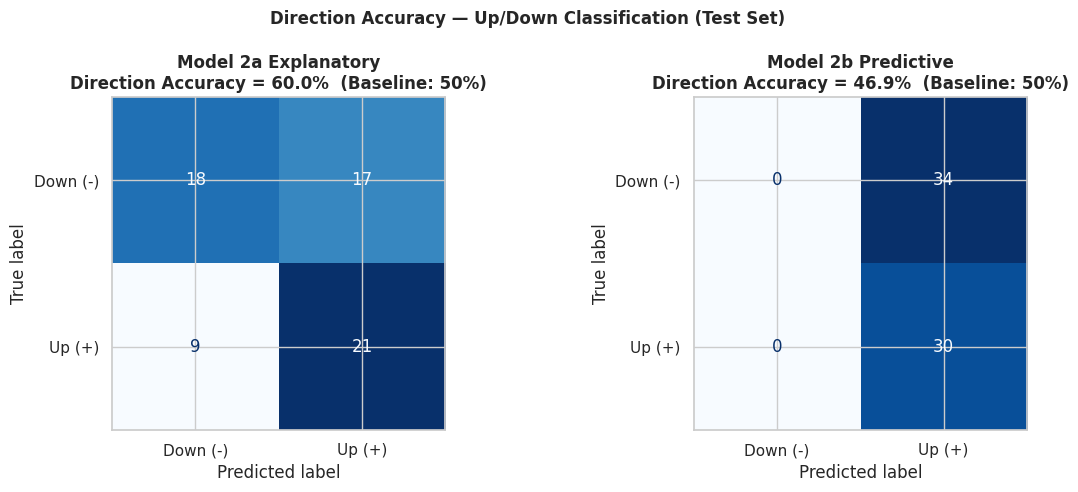

Model 2a direction accuracy (test): 60.0%
Model 2b direction accuracy (test): 46.9%
Random baseline: 50.0%


In [7]:
def direction_accuracy(y_true, y_pred):
    correct = np.sign(y_true) == np.sign(y_pred)
    return correct.mean()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, y_te, yhat_te) in zip(axes, [
    ('2a Explanatory', y_test_2a, yhat_te_2a),
    ('2b Predictive',  y_test_2b, yhat_te_2b),
]):
    dir_acc = direction_accuracy(y_te, yhat_te)

    y_dir    = (y_te > 0).astype(int)
    yhat_dir = (yhat_te > 0).astype(int)
    cm = confusion_matrix(y_dir, yhat_dir)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Down (-)', 'Up (+)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Model {label}\n'
                 f'Direction Accuracy = {dir_acc:.1%}  '
                 f'(Baseline: 50%)',
                 fontweight='bold')

plt.suptitle('Direction Accuracy — Up/Down Classification (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Model 2a direction accuracy (test): {direction_accuracy(y_test_2a, yhat_te_2a):.1%}')
print(f'Model 2b direction accuracy (test): {direction_accuracy(y_test_2b, yhat_te_2b):.1%}')
print(f'Random baseline: 50.0%')

---
## Summary — Model Comparison & Next Steps

In [8]:
print('='*72)
print('LASSO MODEL PERFORMANCE SUMMARY')
print('='*72)
print(f'{'Model':<35} {'Train R²':>9} {'Test R²':>9} {'Test RMSE':>10} {'Features':>9}')
print('-'*72)
for label, metrics, coef_df in [
    ('2a Explanatory (contemp.)',  metrics_2a, coef_2a),
    ('2b Predictive (next-month)', metrics_2b, coef_2b),
]:
    print(f'{label:<35} {metrics["train_r2"]:>9.3f} {metrics["test_r2"]:>9.3f} '
          f'{metrics["test_rmse"]:>10.4f} {len(coef_df):>9}')
print('='*72)

print()
print('SELECTED FEATURES — Model 2a (Explanatory):')
for _, row in coef_2a.sort_values('coef_std').iterrows():
    direction = '↑ SET rises' if row['coef_std'] > 0 else '↓ SET falls'
    print(f'  {row["feature"]:<35} {row["coef_std"]:+.4f}  ({direction})')

print()
print('SELECTED FEATURES — Model 2b (Predictive):')
if len(coef_2b) > 0:
    for _, row in coef_2b.sort_values('coef_std').iterrows():
        direction = '↑ next month rises' if row['coef_std'] > 0 else '↓ next month falls'
        print(f'  {row["feature"]:<35} {row["coef_std"]:+.4f}  ({direction})')
else:
    print('  (LASSO zeroed all features — market returns are close to random walk)')

print()
print('INTERPRETATION:')
print('  R² < 0.1 on test = monthly returns are hard to predict (expected for efficient markets)')
print('  Direction accuracy > 55% = economically useful signal')
print()
print('NEXT STEPS:')
print('  1. Panel OLS (add 5 more countries) → stronger macro inference')
print('  2. Try lag features (SET[t-1], rolling 3m momentum) as additional predictors')
print('  3. Regime-conditional model (separate GFC / COVID / normal periods)')
print('  4. XGBoost as non-linear alternative to LASSO')

LASSO MODEL PERFORMANCE SUMMARY
Model                                Train R²   Test R²  Test RMSE  Features
------------------------------------------------------------------------
2a Explanatory (contemp.)               0.430     0.254     0.0432         4
2b Predictive (next-month)              0.000    -0.009     0.0487         0

SELECTED FEATURES — Model 2a (Explanatory):
  USD_THB_ret_m                       -0.0142  (↓ SET falls)
  th_exchange_rate_real_mom           +0.0012  (↑ SET rises)
  oil_ret_m                           +0.0025  (↑ SET rises)
  sp500_ret_m                         +0.0133  (↑ SET rises)

SELECTED FEATURES — Model 2b (Predictive):
  (LASSO zeroed all features — market returns are close to random walk)

INTERPRETATION:
  R² < 0.1 on test = monthly returns are hard to predict (expected for efficient markets)
  Direction accuracy > 55% = economically useful signal

NEXT STEPS:
  1. Panel OLS (add 5 more countries) → stronger macro inference
  2. Try lag featu